## 0. Environment Setup

In [1]:
import warnings
from datetime import datetime, timedelta

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import RobustScaler, StandardScaler

warnings.filterwarnings("ignore")
plt.style.use("dark_background")

COLORS = {
    "primary": "#4FC3F7",
    "success": "#66BB6A",
    "danger": "#EF5350",
    "warning": "#FFA726",
    "neutral": "#B0BEC5",
}

# Target tickers for feature engineering study
TICKERS = ["SPY", "AAPL", "NVDA"]
END = datetime.today()

# Intra-day interval TFT training input
INTERVAL = "1h"

# Yahoo intraday limits (aprox). Ajusta si quieres.
MAX_LOOKBACK_DAYS = {
    "1m": 7,
    "2m": 60,
    "5m": 60,
    "15m": 60,
    "30m": 60,
    "60m": 730,
    "1h": 730,
    "90m": 60,
}

default_days = 365 * 3
lookback_days = min(default_days, MAX_LOOKBACK_DAYS.get(INTERVAL, default_days))
START = END - timedelta(days=lookback_days)

print(f"Interval: {INTERVAL} | Window : {START.date()} ⟶ {END.date()}")

Interval: 1h | Window : 2024-03-10 ⟶ 2026-03-10


## 1. Raw OHLCV Download

In [2]:
raw: dict[str, pd.DataFrame] = {}
for t in TICKERS:
    df = yf.download(
        t,
        start=START,
        end=END,
        interval=INTERVAL,
        progress=False,
        auto_adjust=True,
    )

    # Normalize columns if yfinance is MultiIndex
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    if df.empty:
        print(f"  {t:<6} ⟶ EMPTY")
        continue

    df.index = pd.to_datetime(df.index, utc=True).tz_convert("America/New_York")
    raw[t] = df
    print(f"  {t:<6} ⟶ {len(df):>5} rows | cols: {list(df.columns)}")

# Work with SPY as the primary study asset
spy = raw["SPY"].copy()
print(f"\nSPY date range: {spy.index[0]} ⟶ {spy.index[-1]}")

  SPY    ⟶  3483 rows | cols: ['Close', 'High', 'Low', 'Open', 'Volume']
  AAPL   ⟶  3483 rows | cols: ['Close', 'High', 'Low', 'Open', 'Volume']
  NVDA   ⟶  3483 rows | cols: ['Close', 'High', 'Low', 'Open', 'Volume']

SPY date range: 2024-03-11 09:30:00-04:00 ⟶ 2026-03-10 15:30:00-04:00


## 2. Technical Indicators — Dynamic Covariates for TFT

In [3]:
def _as_series(df: pd.DataFrame, col: str) -> pd.Series:
    s = df[col]
    if isinstance(s, pd.DataFrame):
        s = s.iloc[:, 0]
    return s.astype(float)


def add_rsi(
    df: pd.DataFrame, period: int = 14, col: str = "Close"
) -> pd.Series:
    close = _as_series(df, col)
    delta = close.diff()
    gain = delta.clip(lower=0).ewm(alpha=1 / period, adjust=False).mean()
    loss = (-delta.clip(upper=0)).ewm(alpha=1 / period, adjust=False).mean()
    rs = gain / loss.replace(0, np.nan)
    return (100 - 100 / (1 + rs)).rename(f"RSI_{period}")


def add_macd(
    df: pd.DataFrame,
    fast: int = 12,
    slow: int = 26,
    signal: int = 9,
    col: str = "Close",
) -> pd.DataFrame:
    close = _as_series(df, col)
    ema_fast = close.ewm(span=fast, adjust=False).mean()
    ema_slow = close.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    return pd.DataFrame(
        {
            "MACD": macd_line,
            "MACD_Signal": signal_line,
            "MACD_Hist": macd_line - signal_line,
        }
    )


def add_bollinger(
    df: pd.DataFrame,
    period: int = 20,
    std_dev: float = 2.0,
    col: str = "Close",
) -> pd.DataFrame:
    close = _as_series(df, col)
    sma = close.rolling(period).mean()
    std = close.rolling(period).std()
    upper = sma + std_dev * std
    lower = sma - std_dev * std
    pct_b = (close - lower) / (upper - lower + 1e-10)
    return pd.DataFrame(
        {
            "BB_Upper": upper,
            "BB_Middle": sma,
            "BB_Lower": lower,
            "BB_PctB": pct_b.clip(0, 1),
            "BB_Width": (upper - lower) / (sma + 1e-10),
        }
    )


def add_atr(df: pd.DataFrame, period: int = 14) -> pd.Series:
    """Average True Range — used for Stop-Distance action head (§5)."""
    high, low, close = df["High"], df["Low"], df["Close"]
    tr = pd.concat(
        [
            high - low,
            (high - close.shift()).abs(),
            (low - close.shift()).abs(),
        ],
        axis=1,
    ).max(axis=1)
    return tr.ewm(alpha=1 / period, adjust=False).mean().rename(f"ATR_{period}")


def add_vwap(df: pd.DataFrame) -> pd.Series:
    """Volume-Weighted Average Price (resets daily)."""
    typical = (df["High"] + df["Low"] + df["Close"]) / 3
    cum_tv = (typical * df["Volume"]).groupby(df.index.date).cumsum()
    cum_vol = df["Volume"].groupby(df.index.date).cumsum()
    return (cum_tv / cum_vol.replace(0, np.nan)).rename("VWAP")


def add_obv(df: pd.DataFrame) -> pd.Series:
    """On-Balance Volume — tracks buying / selling pressure."""
    direction = np.sign(df["Close"].diff().fillna(0))
    return (direction * df["Volume"]).cumsum().rename("OBV")


def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    TFT Known Future Inputs — calendar features the model can use
    to understand seasonality and market microstructure rhythms.
    """
    return pd.DataFrame(
        {
            "hour_sin": np.sin(2 * np.pi * df.index.hour / 24),
            "hour_cos": np.cos(2 * np.pi * df.index.hour / 24),
            "dow_sin": np.sin(2 * np.pi * df.index.dayofweek / 7),
            "dow_cos": np.cos(2 * np.pi * df.index.dayofweek / 7),
            "month_sin": np.sin(2 * np.pi * df.index.month / 12),
            "month_cos": np.cos(2 * np.pi * df.index.month / 12),
            "is_open": ((df.index.hour >= 9) & (df.index.hour < 16)).astype(
                float
            ),
        },
        index=df.index,
    )


# —— Build full feature set for SPY ———————————————————————————————————————————
features = spy.copy()
features = features.join(add_rsi(spy, 14))
features = features.join(add_rsi(spy, 7).rename("RSI_7"))
features = features.join(add_macd(spy))
features = features.join(add_bollinger(spy))
features = features.join(add_atr(spy))
features = features.join(add_vwap(spy))
features = features.join(add_obv(spy))
features = features.join(add_time_features(spy))

# Log return as primary price representation (handles non-stationarity)
features["log_return"] = np.log(spy["Close"] / spy["Close"].shift(1))
features["log_vol_ratio"] = np.log(
    spy["Volume"] / spy["Volume"].shift(1)
).replace(0, np.nan)

features.dropna(inplace=True)
print(f"Feature set shape : {features.shape}")
print(f"Columns ({len(features.columns)}) : {list(features.columns)}")

Feature set shape : (3464, 27)
Columns (27) : ['Close', 'High', 'Low', 'Open', 'Volume', 'RSI_14', 'RSI_7', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper', 'BB_Middle', 'BB_Lower', 'BB_PctB', 'BB_Width', 'ATR_14', 'VWAP', 'OBV', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_open', 'log_return', 'log_vol_ratio']


## 3. Feature Visualisation

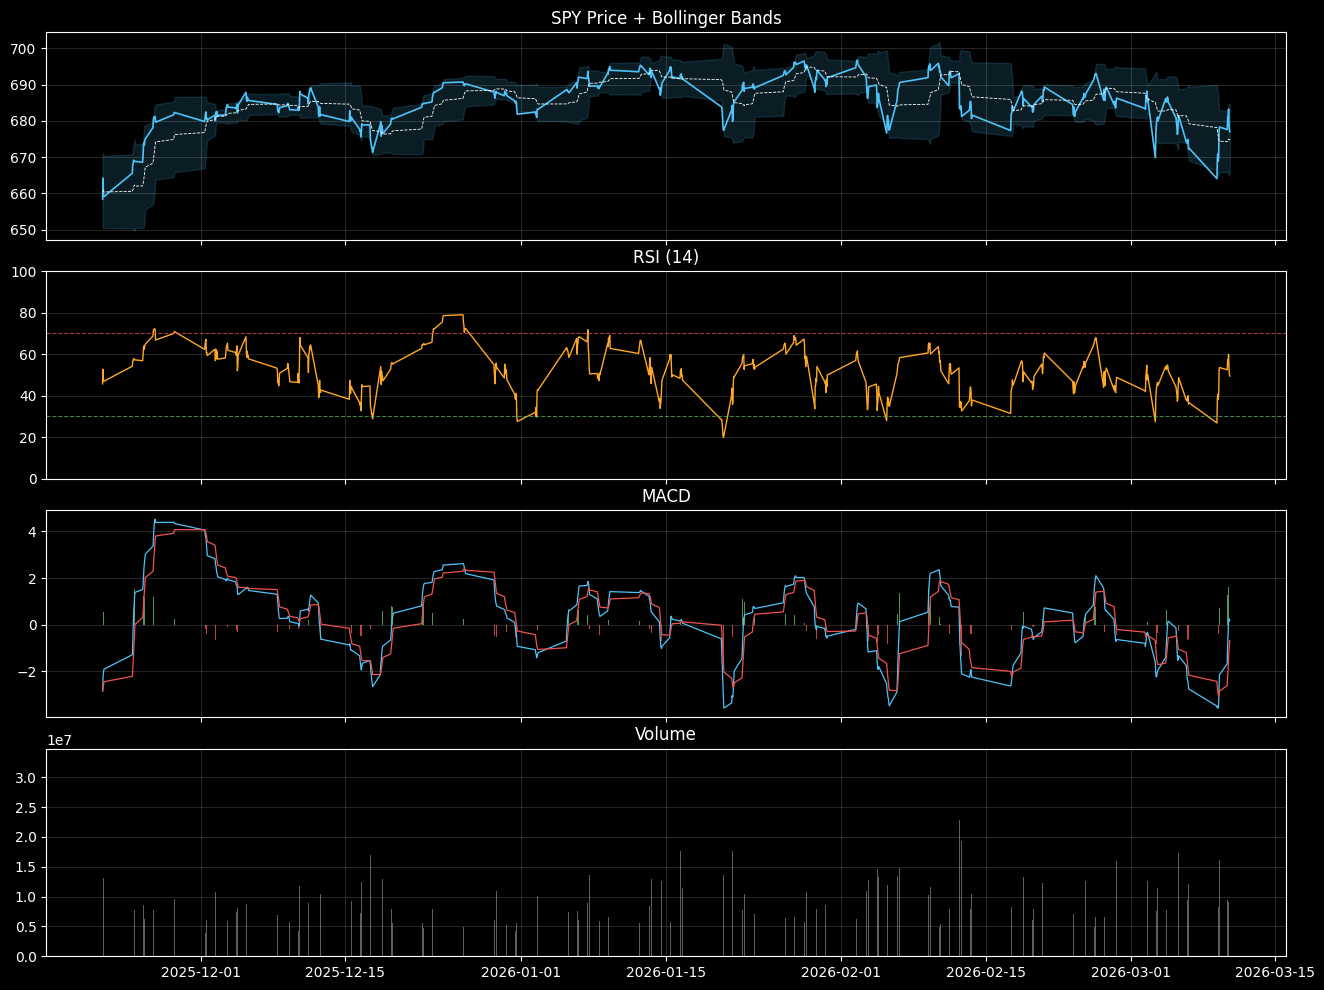

Saved → 02_technical_indicators.png


In [4]:
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(4, 1, hspace=0.15)

sample = features.iloc[-500:]

ax0 = fig.add_subplot(gs[0])
ax0.plot(sample.index, sample["Close"], color=COLORS["primary"], linewidth=1.2)
ax0.fill_between(
    sample.index,
    sample["BB_Lower"],
    sample["BB_Upper"],
    alpha=0.15,
    color=COLORS["primary"],
)
ax0.plot(
    sample.index,
    sample["BB_Middle"],
    color="white",
    linewidth=0.6,
    linestyle="--",
)
ax0.set_title("SPY Price + Bollinger Bands")
ax0.set_xticklabels([])
ax0.grid(alpha=0.15)

ax1 = fig.add_subplot(gs[1])
ax1.plot(sample.index, sample["RSI_14"], color=COLORS["warning"], linewidth=1.0)
ax1.axhline(
    70, color=COLORS["danger"], linestyle="--", alpha=0.7, linewidth=0.8
)
ax1.axhline(
    30, color=COLORS["success"], linestyle="--", alpha=0.7, linewidth=0.8
)
ax1.set_ylim(0, 100)
ax1.set_title("RSI (14)")
ax1.set_xticklabels([])
ax1.grid(alpha=0.15)

ax2 = fig.add_subplot(gs[2])
ax2.bar(
    sample.index,
    sample["MACD_Hist"],
    color=[
        COLORS["success"] if v >= 0 else COLORS["danger"]
        for v in sample["MACD_Hist"]
    ],
    width=0.02,
    alpha=0.8,
)
ax2.plot(sample.index, sample["MACD"], color=COLORS["primary"], linewidth=0.9)
ax2.plot(
    sample.index, sample["MACD_Signal"], color=COLORS["danger"], linewidth=0.9
)
ax2.set_title("MACD")
ax2.set_xticklabels([])
ax2.grid(alpha=0.15)

ax3 = fig.add_subplot(gs[3])
ax3.bar(
    sample.index,
    sample["Volume"],
    color=COLORS["neutral"],
    alpha=0.5,
    width=0.02,
)
ax3.set_title("Volume")
ax3.grid(alpha=0.15)

plt.savefig("02/02_technical_indicators.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 02_technical_indicators.png")

## 4. Static Covariates Schema — TFT Metadata Inputs

In [5]:
# TFT uses static covariates to condition predictions per-asset (§3-A).
# This schema mirrors what backend/perception/temporal/preprocessor.py will
# produce.
STATIC_COVARIATES: dict[str, dict] = {
    "SPY": {
        "asset_class": 0,
        "sector": 0,
        "vol_profile": 1,
        "market_cap_tier": 3,
    },
    "AAPL": {
        "asset_class": 1,
        "sector": 3,
        "vol_profile": 1,
        "market_cap_tier": 3,
    },
    "MSFT": {
        "asset_class": 1,
        "sector": 3,
        "vol_profile": 0,
        "market_cap_tier": 3,
    },
    "NVDA": {
        "asset_class": 1,
        "sector": 3,
        "vol_profile": 2,
        "market_cap_tier": 3,
    },
    "AMD": {
        "asset_class": 1,
        "sector": 3,
        "vol_profile": 2,
        "market_cap_tier": 2,
    },
    "SMCI": {
        "asset_class": 1,
        "sector": 3,
        "vol_profile": 2,
        "market_cap_tier": 1,
    },
    "GLD": {
        "asset_class": 2,
        "sector": 5,
        "vol_profile": 0,
        "market_cap_tier": 2,
    },
    "USO": {
        "asset_class": 2,
        "sector": 6,
        "vol_profile": 1,
        "market_cap_tier": 1,
    },
    "TLT": {
        "asset_class": 3,
        "sector": 7,
        "vol_profile": 0,
        "market_cap_tier": 2,
    },
    "QQQ": {
        "asset_class": 0,
        "sector": 3,
        "vol_profile": 1,
        "market_cap_tier": 3,
    },
}

# Encoding legends for documentation
LEGENDS = {
    "asset_class": {0: "ETF", 1: "Equity", 2: "Commodity", 3: "Bond"},
    "vol_profile": {0: "Low", 1: "Medium", 2: "High"},
    "market_cap_tier": {1: "Small", 2: "Mid", 3: "Large"},
}

df_static = pd.DataFrame(STATIC_COVARIATES).T
print("Static Covariate Matrix:")
print(df_static.to_string())

Static Covariate Matrix:
      asset_class  sector  vol_profile  market_cap_tier
SPY             0       0            1                3
AAPL            1       3            1                3
MSFT            1       3            0                3
NVDA            1       3            2                3
AMD             1       3            2                2
SMCI            1       3            2                1
GLD             2       5            0                2
USO             2       6            1                1
TLT             3       7            0                2
QQQ             0       3            1                3


## 5. Normalisation Strategy

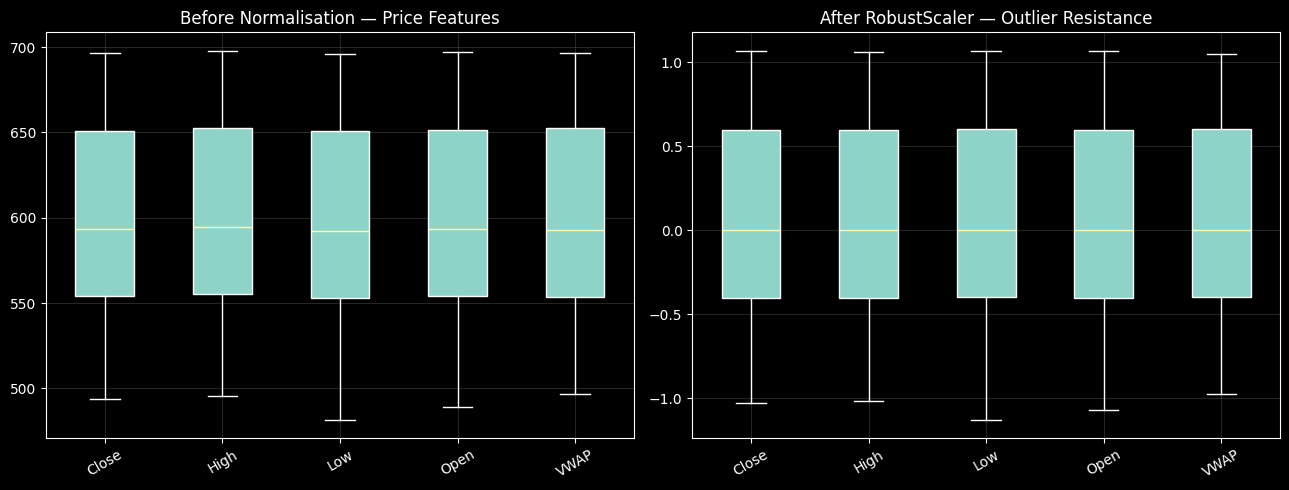

In [6]:
# The TFT is sensitive to scale — wrong normalisation causes gradiente
# explosions.
# We compare three strategies and select RobustScaler for price features.

PRICE_FEATURES = [
    "Close",
    "High",
    "Low",
    "Open",
    "VWAP",
    "BB_Upper",
    "BB_Middle",
    "BB_Lower",
    "ATR_14",
]
BOUNDED_FEATURES = [
    "RSI_14",
    "RSI_7",
    "BB_PctB",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
]
RETURN_FEATURES = [
    "log_return",
    "log_vol_ratio",
    "MACD",
    "MACD_Signal",
    "MACD_Hist",
]

scalers = {
    "RobustScaler": RobustScaler(),
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": None,  # Bounded features only — applied manually
}

X = features[PRICE_FEATURES].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Before normalisation
axes[0].boxplot(
    [X[c].values for c in PRICE_FEATURES[:5]],
    labels=PRICE_FEATURES[:5],
    patch_artist=True,
)
axes[0].set_title("Before Normalisation — Price Features")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(alpha=0.15)

# After RobustScaler
X_robust = pd.DataFrame(
    RobustScaler().fit_transform(X),
    columns=PRICE_FEATURES,
    index=X.index,
)
axes[1].boxplot(
    [X_robust[c].values for c in PRICE_FEATURES[:5]],
    labels=PRICE_FEATURES[:5],
    patch_artist=True,
)
axes[1].set_title("After RobustScaler — Outlier Resistance")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(alpha=0.15)

plt.tight_layout()
plt.savefig("02/02_normalisation.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Feature Correlation with Forward Returns

In [7]:
# Predictive power assessment: which features correlate with 1h
# forward returns?
# This informs the Variable Selection Network prior weighting in
# notebook 06.
HORIZONS = [1, 4, 8, 24]  # hours ahead

fwd_corr_results = {}
for h in HORIZONS:
    fwd_return = features["log_return"].shift(-h)
    numeric_features = features.select_dtypes(include=[np.number]).columns
    corr_series = features[numeric_features].corrwith(fwd_return)
    fwd_corr_results[f"fwd_{h}h"] = corr_series

corr_df = pd.DataFrame(fwd_corr_results)
# Sort by 1-hour forward correlation magnitude
corr_df["abs_1h"] = corr_df["fwd_1h"].abs()
top_features = corr_df.sort_values("abs_1h", ascending=False).head(15)
top_features = top_features.drop(columns="abs_1h")

print("Top 15 features by |correlation| with 1h forward return:")
print(top_features.to_string())

Top 15 features by |correlation| with 1h forward return:
               fwd_1h    fwd_4h    fwd_8h   fwd_24h
ATR_14       0.027594  0.025896  0.025599  0.017407
MACD        -0.027011 -0.016803 -0.014779 -0.015623
RSI_14      -0.024999 -0.019319 -0.009672 -0.018504
dow_cos      0.024775  0.012132  0.008369 -0.001632
OBV         -0.024627 -0.021498 -0.018356 -0.018518
hour_sin    -0.023767  0.001092 -0.025013 -0.009338
BB_PctB     -0.022620 -0.021907 -0.005384 -0.020186
MACD_Signal -0.022414 -0.019059 -0.024922 -0.008290
Open        -0.022279 -0.019384 -0.017762 -0.017503
Low         -0.022277 -0.020171 -0.018253 -0.018625
RSI_7       -0.022265 -0.018312 -0.007376 -0.020751
VWAP        -0.021720 -0.018661 -0.017943 -0.018260
Close       -0.021586 -0.020442 -0.018857 -0.019305
High        -0.020953 -0.020856 -0.018213 -0.017730
month_sin   -0.020526 -0.021045 -0.019845 -0.020233


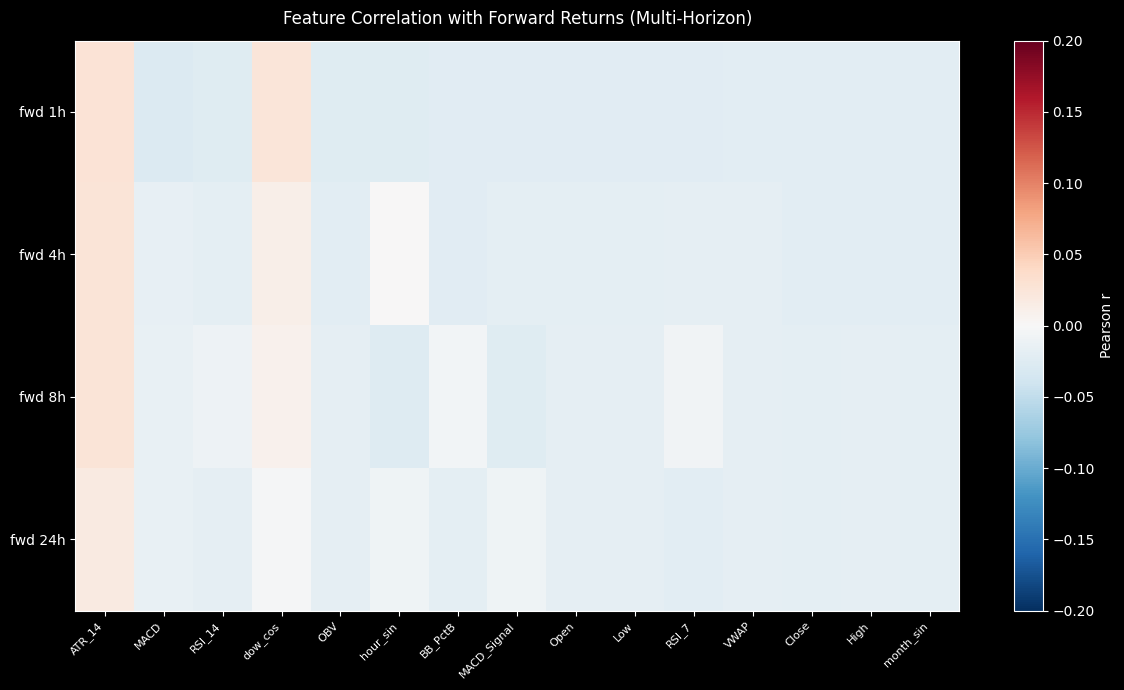

In [8]:
fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(
    top_features.T.values, aspect="auto", cmap="RdBu_r", vmin=-0.2, vmax=0.2
)
ax.set_xticks(range(len(top_features.index)))
ax.set_xticklabels(top_features.index, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(top_features.columns)))
ax.set_yticklabels([f"fwd {h}h" for h in HORIZONS])
ax.set_title(
    "Feature Correlation with Forward Returns (Multi-Horizon)",
    fontsize=12,
    pad=12,
)
plt.colorbar(im, ax=ax, label="Pearson r")
plt.tight_layout()
plt.savefig("02/02_predictive_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Feature Store Schema Preview

In [9]:
# This schema defines the interface between feature_engineering.py and the
# Feature Store (backend/feature_store/definitions.py).
# Each feature group maps to a different TTL and storage backend.
FEATURE_STORE_SCHEMA = {
    "price_features": {
        "features": PRICE_FEATURES,
        "storage": "TimescaleDB (cold)",
        "ttl": "N/A (persistent)",
        "frequency": "1m / 5m / 1h",
    },
    "technical_indicators": {
        "features": [
            "RSI_14",
            "RSI_7",
            "MACD",
            "MACD_Signal",
            "MACD_Hist",
            "BB_Upper",
            "BB_Lower",
            "BB_PctB",
            "BB_Width",
            "ATR_14",
            "VWAP",
            "OBV",
        ],
        "storage": "Redis (hot) + TimescaleDB (cold)",
        "ttl": "120s (Redis TTL_PRICE)",
        "frequency": "1m (computed on new candle)",
    },
    "time_covariates": {
        "features": [
            "hour_sin",
            "hour_cos",
            "dow_sin",
            "dow_cos",
            "month_sin",
            "month_cos",
            "is_open",
        ],
        "storage": "Computed on-the-fly (zero cost)",
        "ttl": "N/A",
        "frequency": "Any",
    },
    "static_covariates": {
        "features": [
            "asset_class",
            "sector",
            "vol_profile",
            "market_cap_tier",
        ],
        "storage": "Redis (hot, permanent)",
        "ttl": "No expiry",
        "frequency": "Updated on corporate actions only",
    },
}

print("Feature Store Schema:")
for group, meta in FEATURE_STORE_SCHEMA.items():
    print(f"\n  [{group}]")
    for k, v in meta.items():
        if isinstance(v, list):
            print(f"    {k:<12}: {len(v)} features — {v[:4]} ...")
        else:
            print(f"    {k:<12}: {v}")

Feature Store Schema:

  [price_features]
    features    : 9 features — ['Close', 'High', 'Low', 'Open'] ...
    storage     : TimescaleDB (cold)
    ttl         : N/A (persistent)
    frequency   : 1m / 5m / 1h

  [technical_indicators]
    features    : 12 features — ['RSI_14', 'RSI_7', 'MACD', 'MACD_Signal'] ...
    storage     : Redis (hot) + TimescaleDB (cold)
    ttl         : 120s (Redis TTL_PRICE)
    frequency   : 1m (computed on new candle)

  [time_covariates]
    features    : 7 features — ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos'] ...
    storage     : Computed on-the-fly (zero cost)
    ttl         : N/A
    frequency   : Any

  [static_covariates]
    features    : 4 features — ['asset_class', 'sector', 'vol_profile', 'market_cap_tier'] ...
    storage     : Redis (hot, permanent)
    ttl         : No expiry
    frequency   : Updated on corporate actions only


## 8. Export Feature Dataset for Notebook 06 (TFT Training)

In [10]:
# Save the engineered feature matrix so the TFT encoder notebook can
# load it without repeating computation.
output_path = "02/02_features_spy.parquet"
features_export = features.dropna()
features_export.to_parquet(output_path)
print(f"Saved feature dataset → {output_path}")
print(f"Shape : {features_export.shape}")
print(f"Memory: {features_export.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# Final feature list for notebook 06 reference
print(f"\nFinal features ({len(features_export.columns)}):")
for i, col in enumerate(features_export.columns):
    print(f"  {i + 1:>3}. {col}")

Saved feature dataset → 02/02_features_spy.parquet
Shape : (3464, 27)
Memory: 0.8 MB

Final features (27):
    1. Close
    2. High
    3. Low
    4. Open
    5. Volume
    6. RSI_14
    7. RSI_7
    8. MACD
    9. MACD_Signal
   10. MACD_Hist
   11. BB_Upper
   12. BB_Middle
   13. BB_Lower
   14. BB_PctB
   15. BB_Width
   16. ATR_14
   17. VWAP
   18. OBV
   19. hour_sin
   20. hour_cos
   21. dow_sin
   22. dow_cos
   23. month_sin
   24. month_cos
   25. is_open
   26. log_return
   27. log_vol_ratio
